In [90]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [91]:
def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)  
    plt.axis('on')

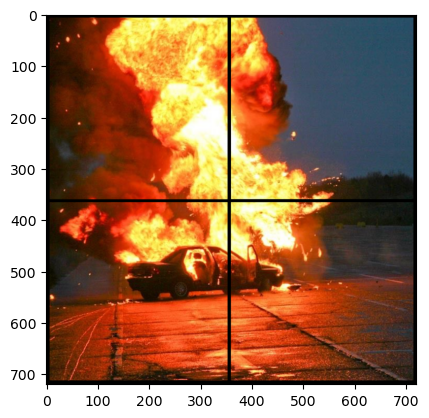

In [92]:
meledak = plt.imread("assets/Meledak.png")
show(meledak)

<Figure size 600x600 with 0 Axes>

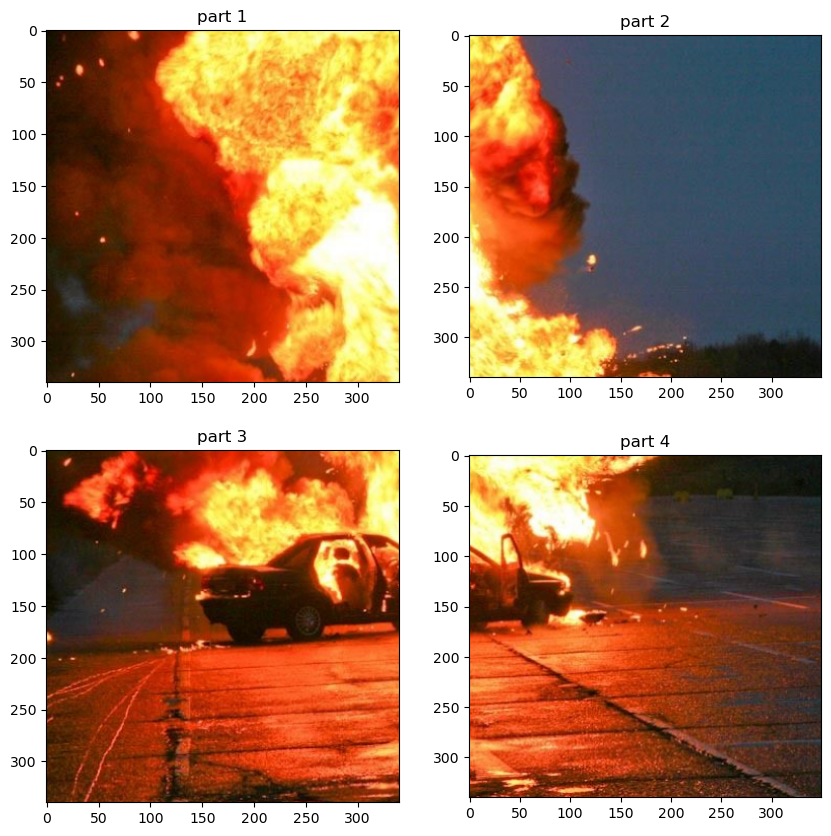

In [93]:
def slicing(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

plt.figure(figsize=(6,6))
vertical1 = slicing(meledak, 10, 350, 'V')
vertical2 = slicing(meledak, 360, 710, 'V')

potongan1 = slicing(vertical1, 10, 350, 'H')
potongan3 = slicing(vertical1, 370, 710, 'H')
potongan2 = slicing(vertical2, 10, 350, 'H')
potongan4 = slicing(vertical2, 370, 710, 'H')

plt.figure(figsize=(10, 20))
plt.subplot(1,2,1)
show(potongan1, "part 1")
plt.subplot(1,2,2)
show(potongan2, "part 2")
plt.subplot(2,2,3)
show(potongan3, "part 3")
plt.subplot(2,2,4)
show(potongan4, "part 4")

In [95]:
def merge_atas(image_1, image_2): 
    c1, c2 = np.array(image_1), np.array(image_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    hasil = np.zeros((tinggi, lebar)).astype(int) 
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil

def merge_bawah(image_3, image_4): 
    c1, c2 = np.array(image_3), np.array(image_4)
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

def merge_semua(img1, img2, img3, img4):
    baris_atas = merge_atas(img1, img2)
    baris_bawah = merge_atas(img3, img4)
    hasil_akhir = merge_bawah(baris_atas, baris_bawah)
    return hasil_akhir
